In [1]:
from sklearn import tree, metrics
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import f1_score
import missingno as msno
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('~/Downloads/loan_approval_dataset.csv')
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [2]:
df.shape

(4269, 13)

# Data Exploration

## Checking Data Completeness and Uniqueness

In [3]:
# Check to see if all entries are unique
df.duplicated().sum()

0

Percentage of Missing Data by Column


loan_id                      0.0
 no_of_dependents            0.0
 education                   0.0
 self_employed               0.0
 income_annum                0.0
 loan_amount                 0.0
 loan_term                   0.0
 cibil_score                 0.0
 residential_assets_value    0.0
 commercial_assets_value     0.0
 luxury_assets_value         0.0
 bank_asset_value            0.0
 loan_status                 0.0
dtype: float64

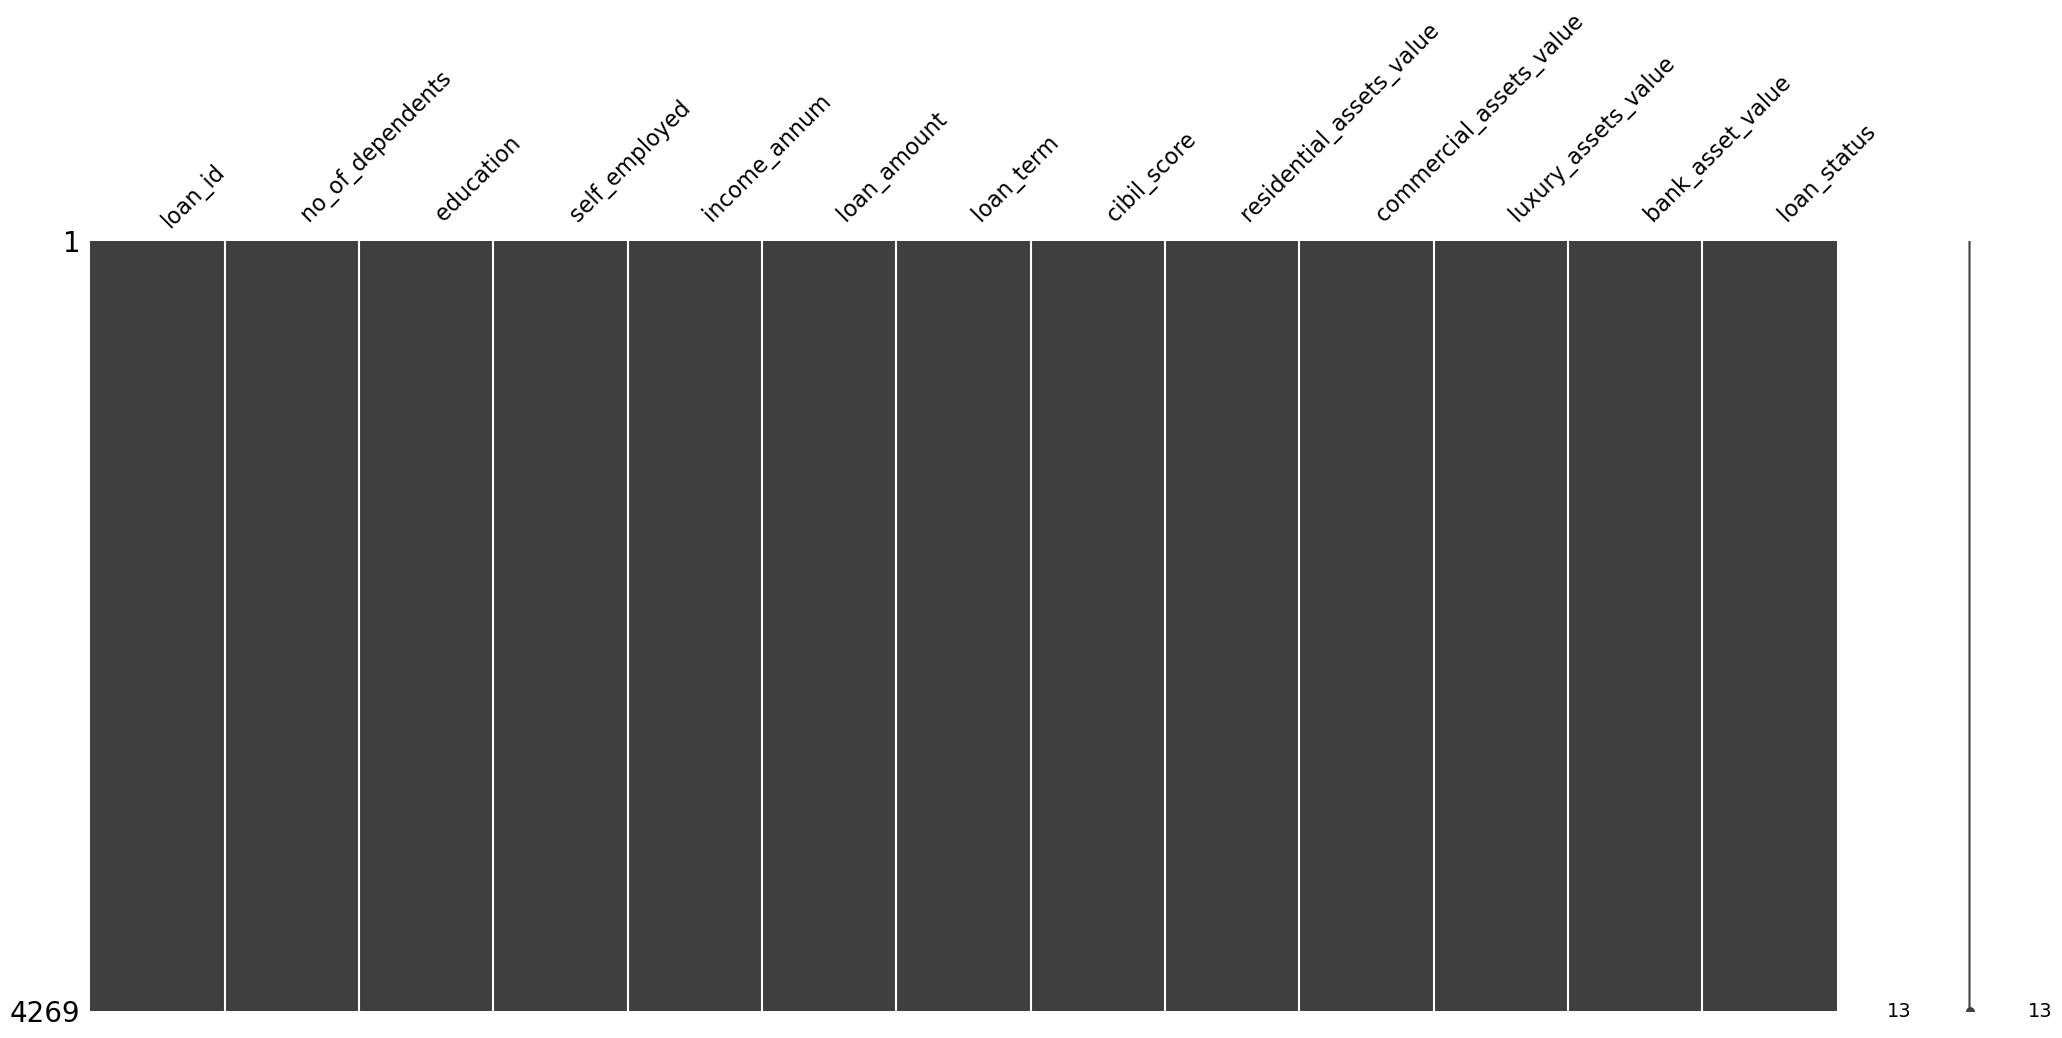

In [4]:
# Graph of missing data
msno.matrix(df)
print("Percentage of Missing Data by Column")
df.isnull().sum()/df.shape[0] * 100 # Percent of Data missing per column

# Removing extra white space in column names

In [5]:
df.columns

Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')

In [6]:
df.columns = df.columns.str.strip()
df.columns

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')

## Univariate Analysis

### Loan Status

 Approved    62.215976
 Rejected    37.784024
Name: loan_status, dtype: float64


<Axes: xlabel='loan_status', ylabel='count'>

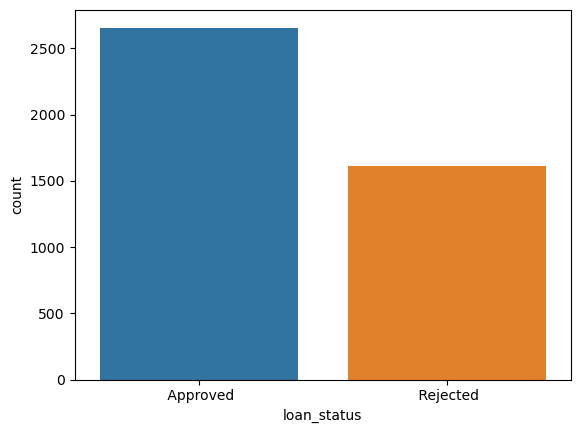

In [7]:
print(df['loan_status'].value_counts()/df.shape[0] * 100)
sns.countplot(x='loan_status', data=df)

In [8]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


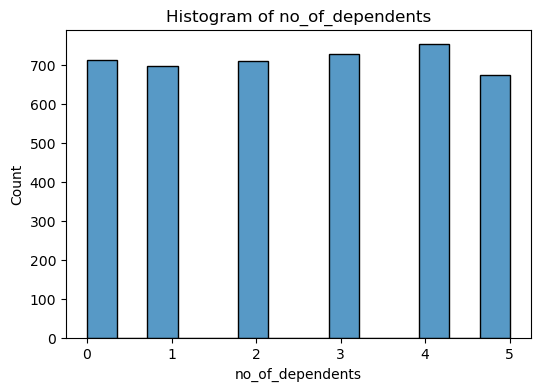

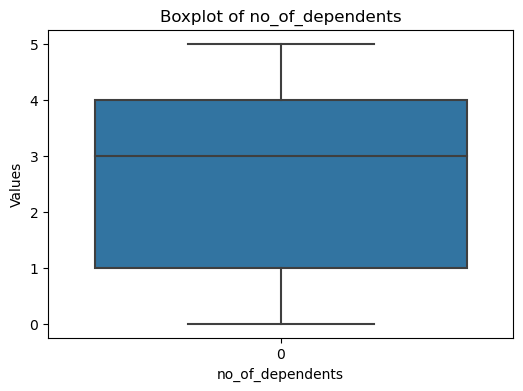

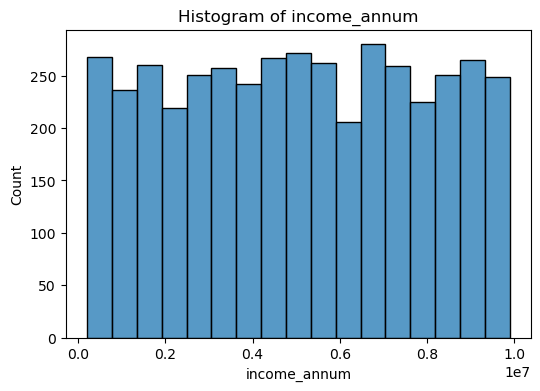

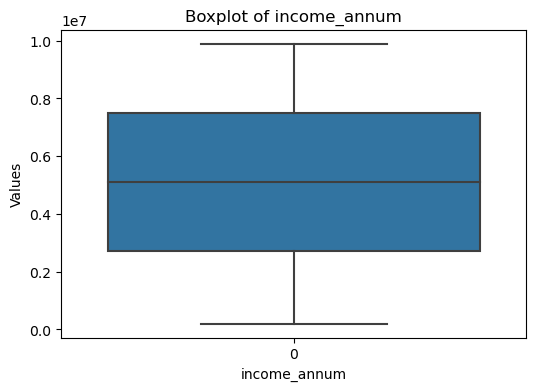

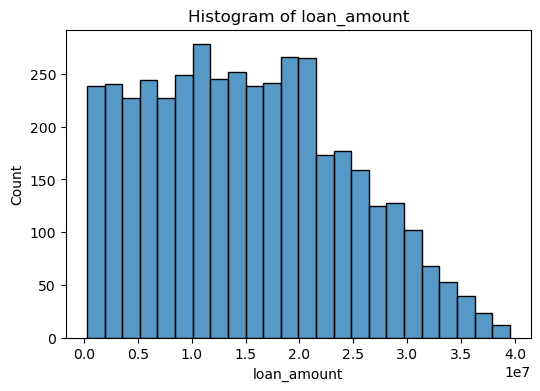

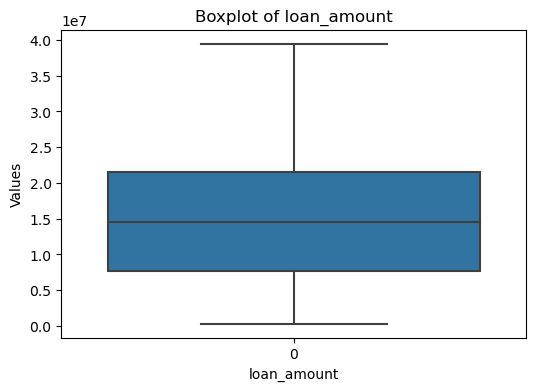

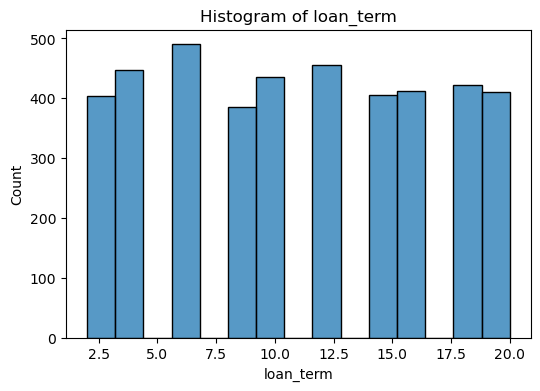

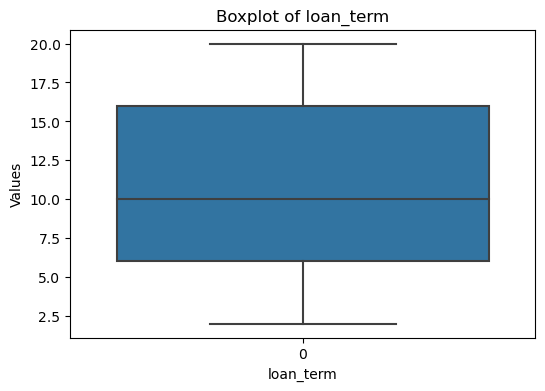

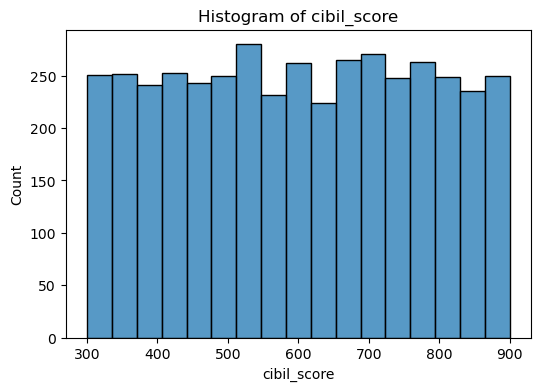

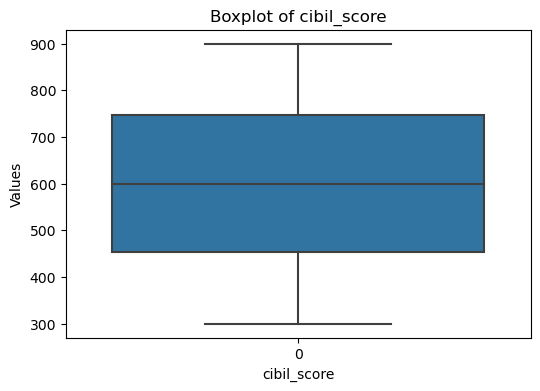

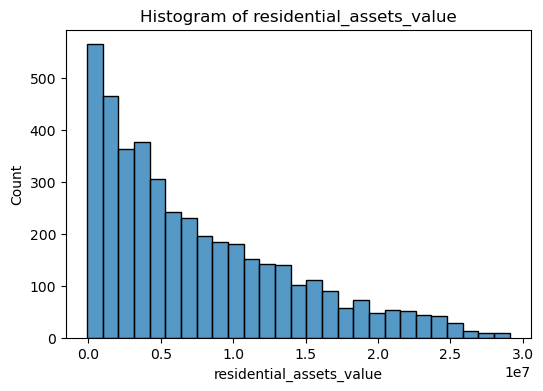

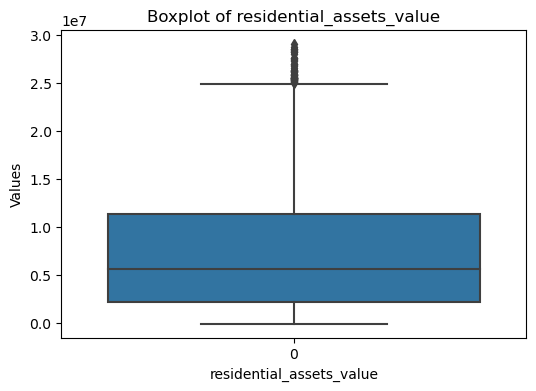

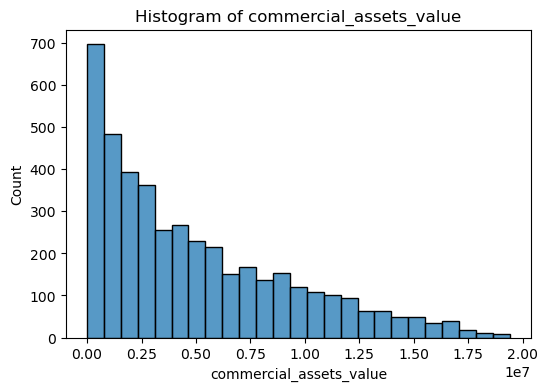

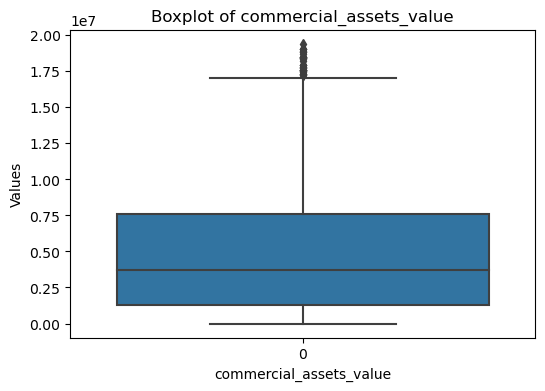

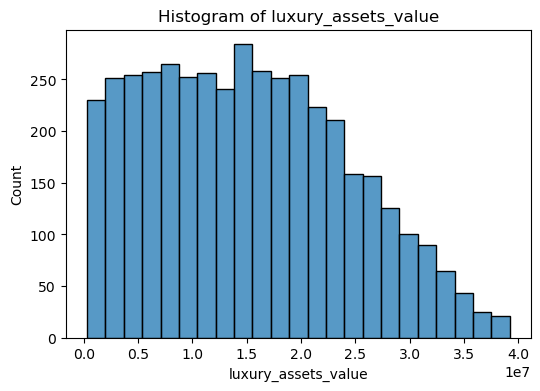

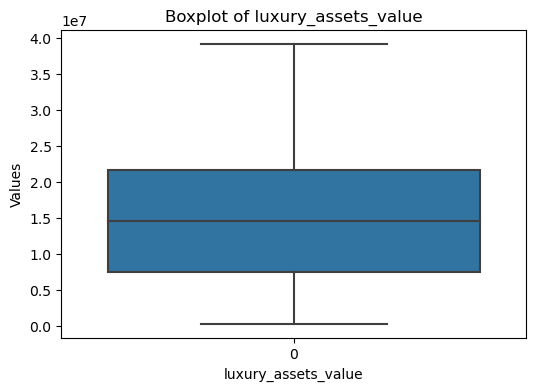

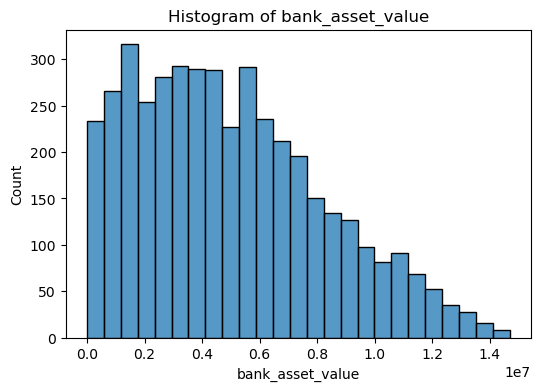

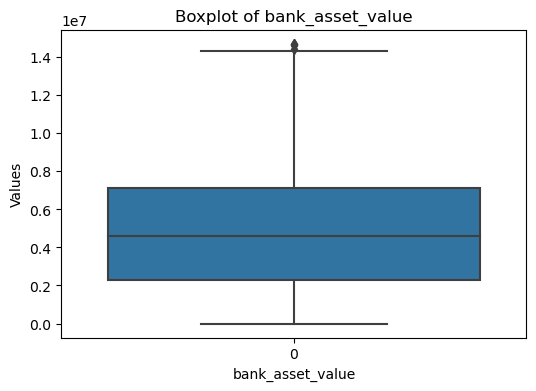

In [9]:
# Plotting Continuous Columns (Histograms and Box Plots)
cont_col = ['no_of_dependents',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value']
for col in cont_col:
    plt.figure(figsize=(6,4))
    plt.title(f'Histogram of {col}')
    plt.xlabel(f'{col}')
    plt.ylabel('Count')
    sns.histplot(df[col])
    plt.show()

    plt.figure(figsize=(6,4))
    plt.title(f'Boxplot of {col}')
    plt.xlabel(f'{col}')
    plt.ylabel('Values')
    sns.boxplot(df[col])
    plt.show()

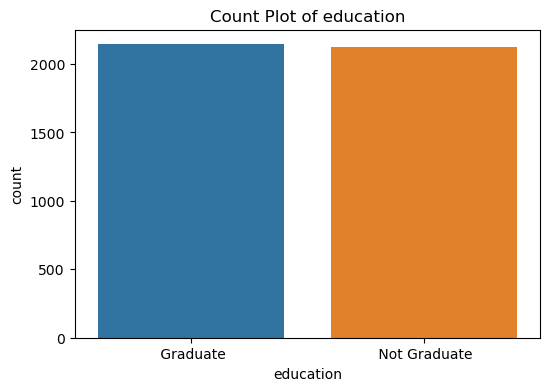

 Graduate        50.222535
 Not Graduate    49.777465
Name: education, dtype: float64


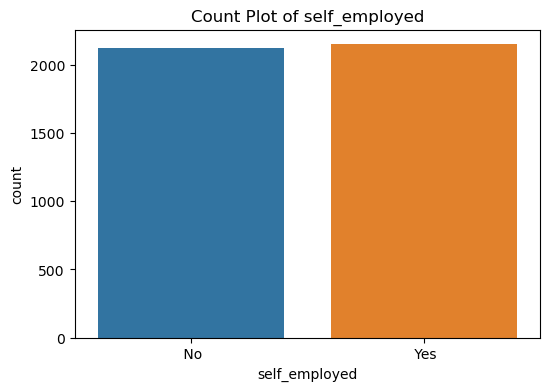

 Yes    50.363083
 No     49.636917
Name: self_employed, dtype: float64


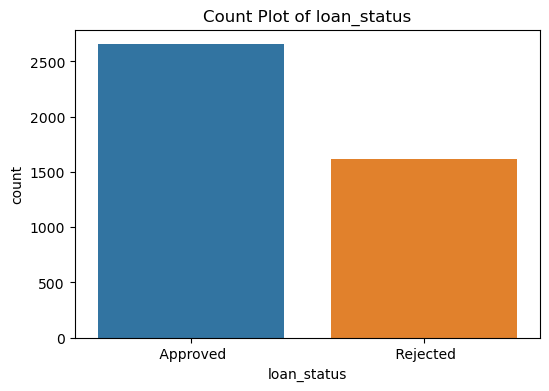

 Approved    62.215976
 Rejected    37.784024
Name: loan_status, dtype: float64


In [10]:
# Plotting Categorical Columns
cat_col = ['education', 'self_employed', 'loan_status']
for col in cat_col:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=df)
    plt.title(f'Count Plot of {col}')
    plt.show()
    print(df[col].value_counts()/df.shape[0] * 100)

## Bivariate Analysis

<Axes: title={'center': 'Correlation Matrix with One Hot Encoding'}>

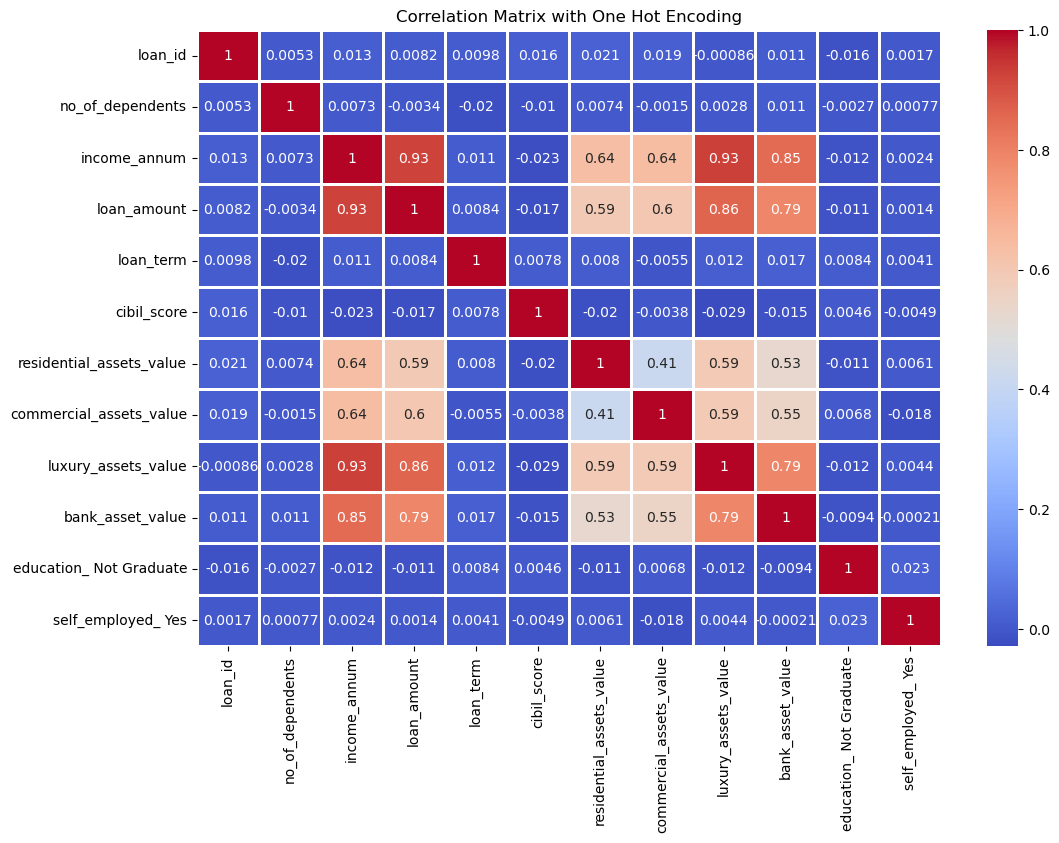

In [11]:
# Correlation matrix with one hot encoding, drop loan status
df_encoded = df.drop(columns='loan_status')
df_encoded = pd.get_dummies(df_encoded, drop_first=True)
corr = df_encoded.corr()

plt.figure(figsize=(12,8))
plt.title('Correlation Matrix with One Hot Encoding')
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=1)

loan_amount income_annum 0.9274699109871472
luxury_assets_value income_annum 0.9291454207522614


<Axes: title={'center': 'Correlation Matrix with Removed High Correlation Variables'}>

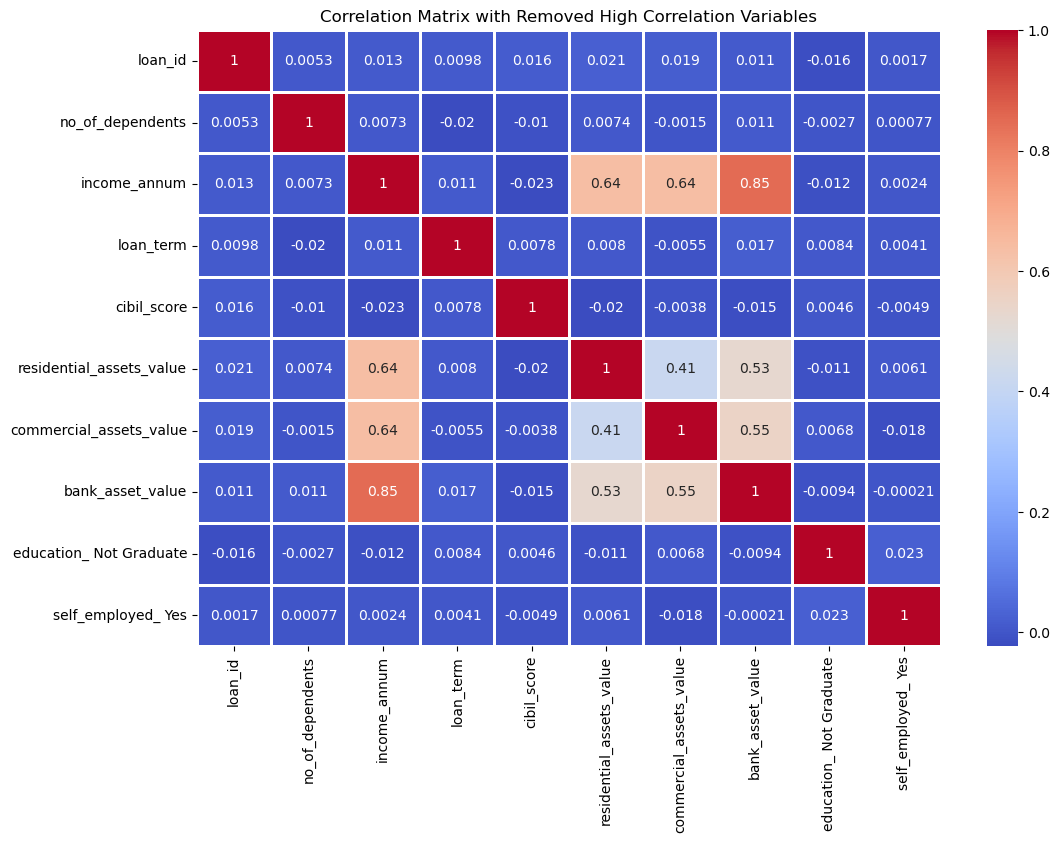

In [12]:
corr_drop = []
for row in corr.index:
    for col in corr.columns:
        if (row == col): 
            break
        if corr.loc[row, col] >= 0.9:
            print(row, col, corr.loc[row,col])
            corr_drop.append(row)

df_encoded = df_encoded.drop(columns=corr_drop)
corr = df_encoded.corr()
plt.figure(figsize=(12,8))
plt.title('Correlation Matrix with Removed High Correlation Variables')
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=1)

## Correlation of Variables with Target Variable Loan Status

Text(0.5, 0, 'Correlation')

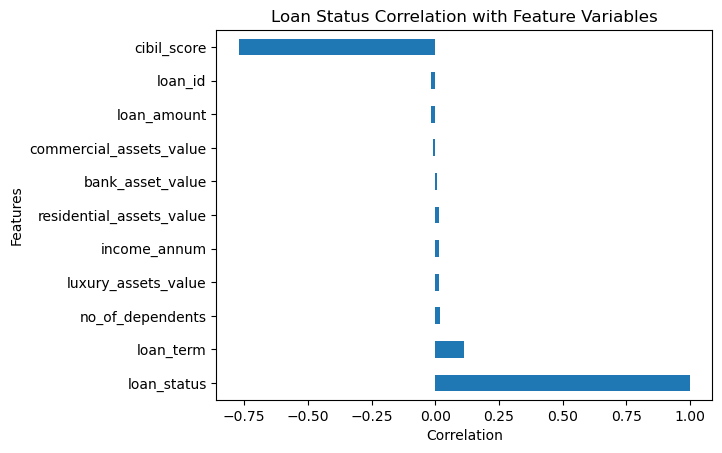

In [13]:
df["loan_status"] = df["loan_status"].str.strip().map({"Approved": 0, "Rejected": 1})
loan_corr = df.corr(numeric_only=True)["loan_status"].sort_values(ascending=False)

loan_corr.plot(kind='barh')
plt.title('Loan Status Correlation with Feature Variables')
plt.ylabel('Features')
plt.xlabel('Correlation')

# Splitting into Training and Test Set

In [14]:
# Defining the predictor variables (X) and target variable (y)
X = df_encoded.drop(columns=['loan_id'])
y = df['loan_status']
X.head()

,no_of_dependents,income_annum,loan_term,cibil_score,residential_assets_value,commercial_assets_value,bank_asset_value,education_ Not Graduate,self_employed_ Yes
0,2,9600000,12,778,2400000,17600000,8000000,0,0
1,0,4100000,8,417,2700000,2200000,3300000,1,1
2,3,9100000,20,506,7100000,4500000,12800000,0,0
3,3,8200000,8,467,18200000,3300000,7900000,0,0
4,5,9800000,20,382,12400000,8200000,5000000,1,1


In [15]:
y.head()

0    0
1    1
2    1
3    1
4    1
Name: loan_status, dtype: int64

In [16]:
# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=19,
    stratify=y
)

In [17]:
# split columns names into continuous and categorical columns
cont_cols = X.select_dtypes(include="number").columns
cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns

# Building Preprocessing For Pipeline.

In [18]:
# Define Preprocessing for pipeline
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), cont_cols),
        # Categorical variables don't need to be preprocessed,
        # were already one hot encoded previously
    ],
    remainder="passthrough"
)

# CART Model

In [19]:
# Cart Pipeline
# RFE was not used because we only have 9 predictor variables
cart_pipe = Pipeline([
    ('prep', preprocess),
    ('model', DecisionTreeClassifier(random_state=19))
])

In [20]:
# Define Parameter Grid
p_grid = {
    "model__max_depth": [None, 3, 5, 8, 12],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 5, 10],
    "model__max_leaf_nodes": [None, 10, 20, 50, 100],
    "model__ccp_alpha": [0.0, 0.0001, 0.001, 0.01]
}

In [21]:
# Tune Hyper Parameters with Grid Search
gs_cart = GridSearchCV(
    estimator=cart_pipe,
    param_grid=p_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    refit=True
)

# Get Scores for tuned models
gs_cart.fit(X_train, y_train)
y_pred = gs_cart.predict(X_test)

cart_model = gs_cart.best_estimator_
cart_scores = [ cart_model.score(X_test, y_test),
                f1_score(y_test, y_pred)]

print('Cart Model:')
print(f'Accuracy: {cart_scores[0]},\nF1: {cart_scores[1]}')

Cart Model:
Accuracy: 0.9566744730679156,
F1: 0.9426356589147287


# Support Vector Machine

In [22]:
# Support Vector Machine Pipeline
svm_pipe = Pipeline([
    ('prep', preprocess),
    ('model', SVC(kernel='rbf', C=1.0, gamma='scale'))
])

In [23]:
# Parameter Grid for SVM
p_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__gamma": ["scale", 0.001, 0.01, 0.1],
    "model__kernel": ["rbf", "linear"]
}

In [24]:
# Tune Hyper Parameters with Grid Search
gs_svm = GridSearchCV(
    estimator=svm_pipe,
    param_grid=p_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    refit=True
)

# Get Scores for tuned models
gs_svm.fit(X_train, y_train)
y_pred = gs_svm.predict(X_test)

svm_model = gs_svm.best_estimator_
svm_scores = [ svm_model.score(X_test, y_test),
                f1_score(y_test, y_pred)]

print('Support Vector Machine:')
print(f'Accuracy: {svm_scores[0]},\nF1: {svm_scores[1]}')

Support Vector Machine:
Accuracy: 0.9344262295081968,
F1: 0.9148936170212766


# Random Forest Model

In [25]:
# Random Forest Pipeline
rf_pipe = Pipeline([
    ('prep', preprocess),
    ('model', RandomForestClassifier(
        n_estimators=500,
        random_state=19,
        n_jobs=-1
    ))
])

In [26]:
# Random Forest Parameter Grid
p_grid = {
    "model__n_estimators": [500, 750, 1000],
    "model__min_samples_leaf": [1, 2, 5, 10],
    "model__max_features": ["sqrt", "log2", None],
}

In [27]:
# Tune Hyper Parameters with Grid Search
gs_rf = GridSearchCV(
    estimator=rf_pipe,
    param_grid=p_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    refit=True
)

# Get Scores for tuned models
gs_rf.fit(X_train, y_train)
y_pred = gs_rf.predict(X_test)

rf_model = gs_rf.best_estimator_
rf_scores = [ rf_model.score(X_test, y_test),
                f1_score(y_test, y_pred)]

print('Random Forest Model:')
print(f'Accuracy: {rf_scores[0]},\nF1: {rf_scores[1]}')

Random Forest Model:
Accuracy: 0.9672131147540983,
F1: 0.9562499999999999


                         feature  importance
3               num__cibil_score   84.022247
2                 num__loan_term    6.082978
4  num__residential_assets_value    2.179739
5   num__commercial_assets_value    2.101719
6          num__bank_asset_value    1.967370
1              num__income_annum    1.925435
0          num__no_of_dependents    1.067702
8        num__self_employed_ Yes    0.348613
7   num__education_ Not Graduate    0.304195


Text(0.5, 0, 'Score')

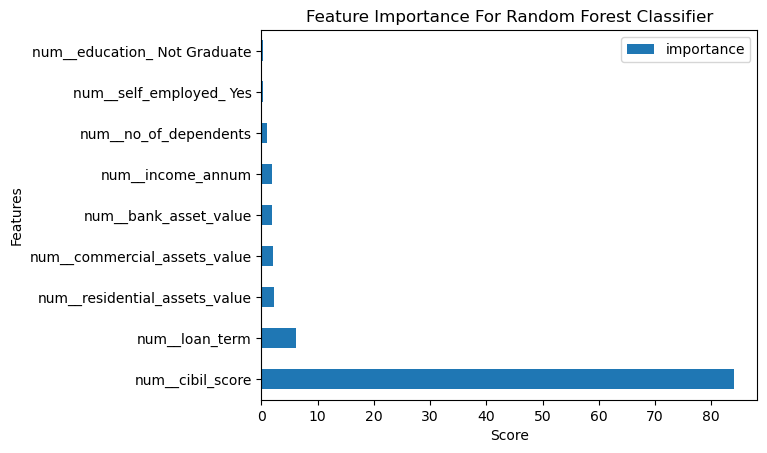

In [28]:
# Feature Importance Random Forest

# Extract importances
feature_names = rf_model.named_steps["prep"].get_feature_names_out()
rf = rf_model.named_steps["model"]
importances = rf.feature_importances_

# Create sorted dataframe
feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances * 100
}).sort_values("importance", ascending=False)

print(feat_imp)
feat_imp.set_index('feature').plot(kind='barh')
plt.title('Feature Importance For Random Forest Classifier')
plt.ylabel('Features')
plt.xlabel('Score')

## Feature Importance for Random Forest Classifier
Most features were relatively unimportant for determining the target variable 'loan_status'. The most important feature with a score of 0.84 was the cibil_score with the second closest feature being the loan_term at only 0.06. These two variables together accounted for 0.9 of impurity reduction. All other features were relatively unimportant being less than 0.02 each.

Essentially what this tells us is that if the Cibil_score is strong enough, no other feature practically matters.

# K-Nearest Neighbor Classifier

In [29]:
knn_scores = []
ks = range(1,27, 2)

for k in ks:

    # Pipeline
    knn_pipe = Pipeline([
        ('prep', preprocess),
        ('model', KNeighborsClassifier(n_neighbors=k, weights='distance'))
    ])

    # Fit with difference K values for n_neighbors
    knn_pipe.fit(X_train, y_train)
    y_pred = knn_pipe.predict(X_test)

    # Calculate and store F1 scores to find best K
    knn_scores.append(f1_score(y_test, y_pred))

# Print F1 scores for K values
for i in range(len(ks)):
    print(f'K={ks[i]}: {knn_scores[i]}')

# Print Best K Value
best_k = ks[int(np.argmax(knn_scores))]
print(f"\nBest k: {best_k}, F1: {max(knn_scores)}")

K=1: 0.8226059654631084
K=3: 0.846875
K=5: 0.8584758942457232
K=7: 0.8705148205928236
K=9: 0.8701095461658842
K=11: 0.8864696734059098
K=13: 0.8854489164086686
K=15: 0.8947368421052632
K=17: 0.891640866873065
K=19: 0.8865030674846627
K=21: 0.8782742681047765
K=23: 0.8813559322033898
K=25: 0.8827160493827161

Best k: 15, F1: 0.8947368421052632


In [30]:
# Fit model with best value for K
k = best_k
knn_pipe.fit(X_train, y_train)
y_pred = knn_pipe.predict(X_test)

In [31]:
knn_scores = [knn_pipe.score(X_test, y_test), f1_score(y_test, y_pred)]
print(f'Accuracy: {knn_scores[0]}, F1: {knn_scores[1]}')

Accuracy: 0.9110070257611241, F1: 0.8827160493827161


# Comparing Models


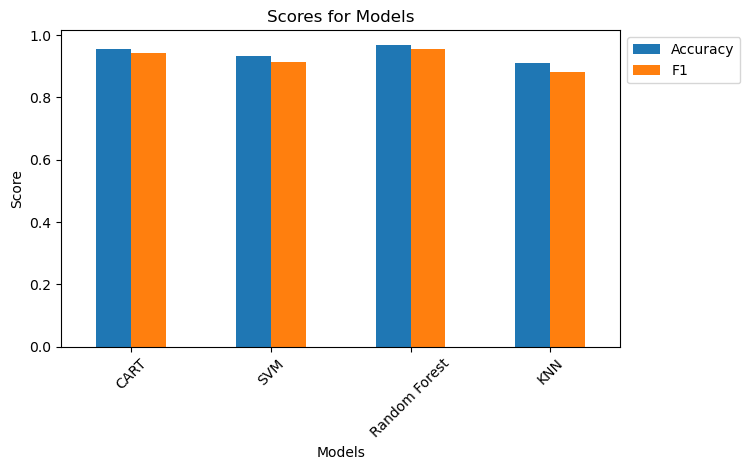

In [32]:
results = pd.DataFrame({
    "Model": ["CART", "SVM", "Random Forest", "KNN"],
    "Accuracy": [
        cart_scores[0],
        svm_scores[0],
        rf_scores[0],
        knn_scores[0]
    ],
    "F1": [
        cart_scores[1],
        svm_scores[1],
        rf_scores[1],
        knn_scores[1]
    ]
})

results.set_index('Model').plot(kind='bar')
plt.title('Scores for Models')
plt.xlabel('Models')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))  # move legend outside

In [33]:
# Sort by Accuracy
results.sort_values('Accuracy', ascending=False)

,Model,Accuracy,F1
2,Random Forest,0.967213,0.956250
0,CART,0.956674,0.942636
1,SVM,0.934426,0.914894
3,KNN,0.911007,0.882716


In [34]:
# Sort by F1
results.sort_values('F1', ascending=False)

,Model,Accuracy,F1
2,Random Forest,0.967213,0.956250
0,CART,0.956674,0.942636
1,SVM,0.934426,0.914894
3,KNN,0.911007,0.882716


# Final Summary

The strongest model trained was the random forest classifier with the highest accuracy and F1 scores: 0.967 and 0.956 respectively. For accuracy, the models ranked Random Forest Classifier, CART, Support Vector Machine, and KNN classifier. The models ranked the same for F1 as well. In the Random Forest Classifier, the most important feature was the 'cibil_score' which accounted for 0.84 of all impurity reduction on the nodes. The second most important feature was the 'loan_term' at a moderate 0.06. All other features contributed less than 0.02. Essentially, according to this model, if the 'cibil_score' was strong enough, all other features were relatively meaningless. 

Many improvements could be made to the models created above. Hyper Parameter tuning could be expanded and use randomized search tuning instead. While this would be more computationally expensive, it should improve the performance of the models. Other Models could also be implemented for example the XGBoost Classifier. Feature reduction could also be performed on all the models. While feature reduction was done by removing highly correlated variables, other variables such as self employment status and education could also be removed since these scored lowest in feature importance for the random forest classifier.

In conclusion, the best performing model was the random forest classifier which scored the highest in terms of accuracy and f1 score. This model was able to correct classify loan status 97% of the time with an f1 score of 0.96.

